In [6]:
"""
AIM:
To perform upsampling, apply different interpolation methods,
perform downsampling and visualize grouped summary on time series data.
"""

'\nAIM:\nTo perform upsampling, apply different interpolation methods,\nperform downsampling and visualize grouped summary on time series data.\n'

In [ ]:
# PROCEDURE – SHAMPOO DATASET
# 1. Import required libraries (pandas, numpy, matplotlib).
# 2. Load the shampoo sales dataset using pandas.
# 3. Convert the Month column into datetime format.
# 4. Set the Month column as index to create a time series.
# 5. Visualize the original dataset using a line plot.
# 6. Perform upsampling to increase frequency.
# 7. Apply interpolation to fill missing values.
# 8. Perform quarterly downsampling using resample().
# 9. Plot the downsampled data using a line graph.
# 10. Group the data by year and visualize summary.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

In [8]:
df = pd.read_csv('shampoo_sales.csv')

# Fix year format like 1-01 → 1901-01
df['Month'] = '190' + df['Month'].astype(str)
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')

df.set_index('Month', inplace=True)

print("Shampoo Dataset:")
print(df.head())

Shampoo Dataset:
            Sales
Month            
1901-01-01  266.0
1901-02-01  145.9
1901-03-01  183.1
1901-04-01  119.3
1901-05-01  180.3


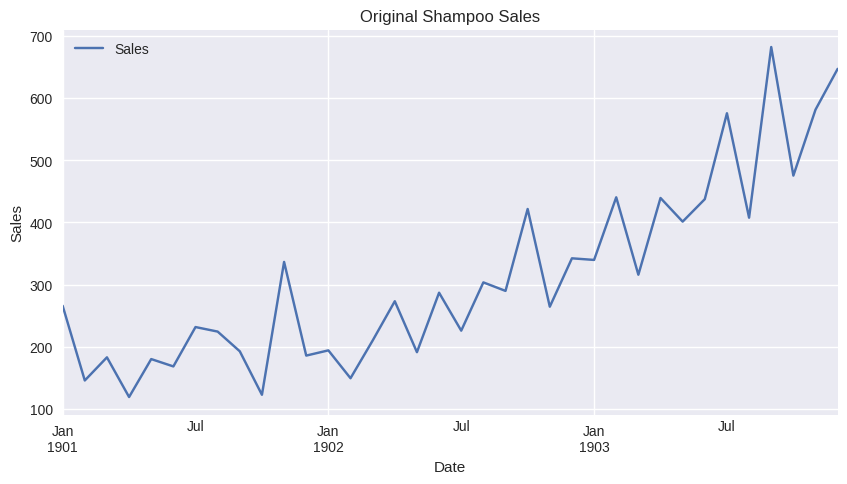

In [9]:

df.plot(figsize=(10,5), title='Original Shampoo Sales')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [10]:
upsampled = df.resample('D').mean()

# Interpolation methods
linear_interp = upsampled.interpolate(method='linear')
ffill_interp = upsampled.fillna(method='ffill')
poly_interp = upsampled.interpolate(method='polynomial', order=2)

print("\nUpsampled Data (Linear Interpolation):")
print(linear_interp.head())


Upsampled Data (Linear Interpolation):
                 Sales
Month                 
1901-01-01  266.000000
1901-01-02  262.125806
1901-01-03  258.251613
1901-01-04  254.377419
1901-01-05  250.503226


/tmp/ipython-input-4129638424.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ffill_interp = upsampled.fillna(method='ffill')


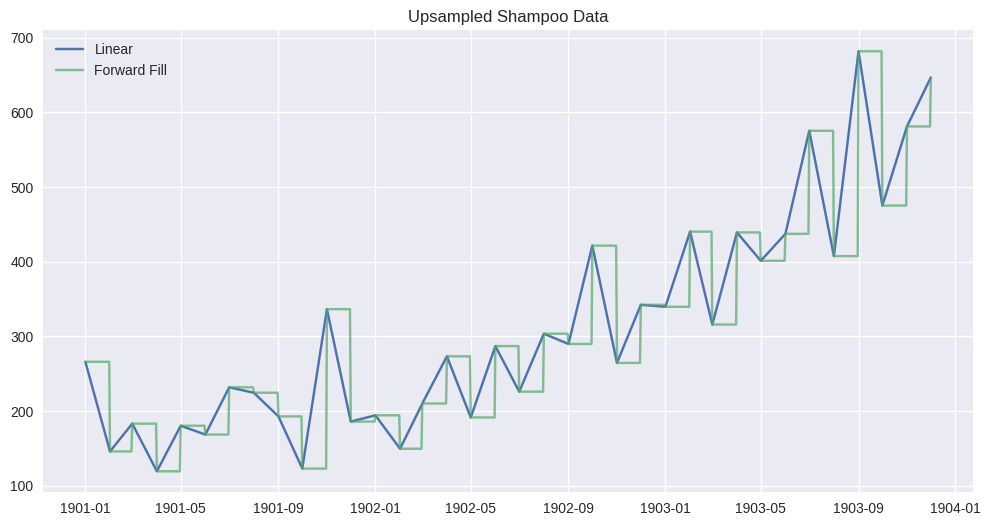

In [11]:
# Plot interpolation
plt.figure(figsize=(12,6))
plt.plot(linear_interp, label='Linear')
plt.plot(ffill_interp, label='Forward Fill', alpha=0.7)
plt.legend()
plt.title("Upsampled Shampoo Data")
plt.show()

/tmp/ipython-input-2219884386.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  downsampled = df.resample('Q').mean()



Quarterly Downsampled Data:
                 Sales
Month                 
1901-03-31  198.333333
1901-06-30  156.033333
1901-09-30  216.366667
1901-12-31  215.100000
1902-03-31  184.633333
1902-06-30  250.566667
1902-09-30  273.166667
1902-12-31  342.800000
1903-03-31  365.333333
1903-06-30  426.000000
1903-09-30  555.033333
1903-12-31  567.833333


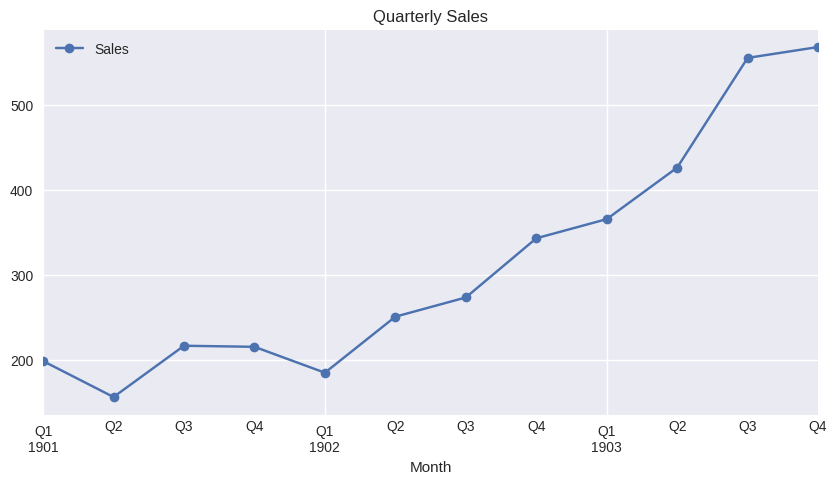

In [12]:
# DOWNSAMPLING (Monthly → Quarterly)
downsampled = df.resample('Q').mean()

print("\nQuarterly Downsampled Data:")
print(downsampled)

downsampled.plot(figsize=(10,5), marker='o', title='Quarterly Sales')
plt.show()


Yearly Summary:
            Sales
Month            
1901   196.458333
1902   262.791667
1903   478.550000


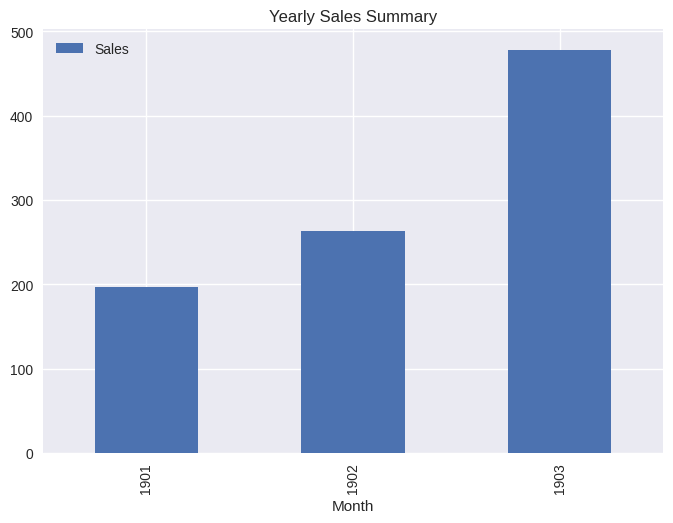

In [13]:
# GROUPED SUMMARY

year_summary = df.groupby(df.index.year).mean()

print("\nYearly Summary:")
print(year_summary)

year_summary.plot(kind='bar', title='Yearly Sales Summary')
plt.show()

In [14]:
"""
RESULT:
Upsampling and interpolation were successfully performed.
Downsampling was applied.
Grouped summaries were visualized.
Experiment 4 completed successfully.
"""

'\nRESULT:\nUpsampling and interpolation were successfully performed.\nDownsampling was applied.\nGrouped summaries were visualized.\nExperiment 4 completed successfully.\n'